In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.models  import Sequential
from tensorflow.keras.metrics import Accuracy 
from tensorflow.keras.layers import Dense, Conv2D, AveragePooling2D,Flatten,BatchNormalization, Dropout

from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Data Processing

In [2]:
# Redefine the generator with correct 1./255 scaling
data_generator = ImageDataGenerator(rescale = 1./255, validation_split = 0.2,
                                    zoom_range=0.2, 
                                    horizontal_flip=True,
                                    width_shift_range= 0.1, 
                                    height_shift_range= 0.1,  
                                    shear_range = 0.1  
                                   )
image_size = (224,224)
train_generator = data_generator.flow_from_directory(
                                    r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Car_Bike_Dataset", 
                                    target_size=image_size, 
                                    batch_size=32,
                                    class_mode='binary', # Changed to binary
                                    subset='training')

val_generator = data_generator.flow_from_directory(
                                    r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Car_Bike_Dataset",
                                    target_size=image_size, 
                                    batch_size=32, 
                                    class_mode='binary', # Changed to binary
                                    subset='validation')

Found 529 images belonging to 2 classes.
Found 131 images belonging to 2 classes.


### Model Building

In [4]:
model = Sequential()

# ---------CNN Layer---------
# 1st convolution layer
model.add(Conv2D(filters = 32, kernel_size = (3,3), strides = (1,1), activation = 'relu', input_shape = image_size +(3,)))
model.add(BatchNormalization()) # Stabilizes the outputs of the convolution
model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Dropout(0.25)) # Randomly drops 25% of connections

# 2nd convolution layer
# Note: input_shape is only needed on the very first layer, so it is removed here.
model.add(Conv2D(filters = 16, kernel_size = (3,3), strides = (1,1), activation = 'relu'))
model.add(BatchNormalization())
model.add(AveragePooling2D(pool_size=(2,2))) 
model.add(Dropout(0.25))

model.add(Flatten())

#--------MLP Layer----------
model.add(Dense(units = 32, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5)) # Higher dropout (e.g., 50%) is common in fully connected layers

model.add(Dense(units = 16, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units= 1, activation = 'sigmoid')) 

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 16)        │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 54, 54, 16)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54, 54, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 46656)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │       1,493,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,499,473 (5.72 MB)

 Trainable params: 1,499,281 (5.72 MB)

 Non-trainable params: 192 (768.00 B)

In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# 2. Compile the model (using categorical_crossentropy for your 4 classes)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Train the model with callbacks included
history = model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=100, 
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    batch_size = 32
)

Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.5255 - loss: 0.8833 - val_accuracy: 0.5954 - val_loss: 0.8670 - learning_rate: 0.0010
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6333 - loss: 0.7081 - val_accuracy: 0.6947 - val_loss: 0.5745 - learning_rate: 0.0010
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6503 - loss: 0.6769 - val_accuracy: 0.6260 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6484 - loss: 0.6652 - val_accuracy: 0.6260 - val_loss: 0.6007 - learning_rate: 0.0010
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.6957 - loss: 0.5937 - val_accuracy: 0.3969 - val_loss: 0.8473 - learning_rate: 0.0010
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7183 - loss: 0.5698 - val_accuracy: 0.3969 - val_loss: 0.8324 - learning_rate: 2.0000e-04
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 17s 991ms/step - accuracy: 0.7164 - loss: 0.5518 - 

In [6]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

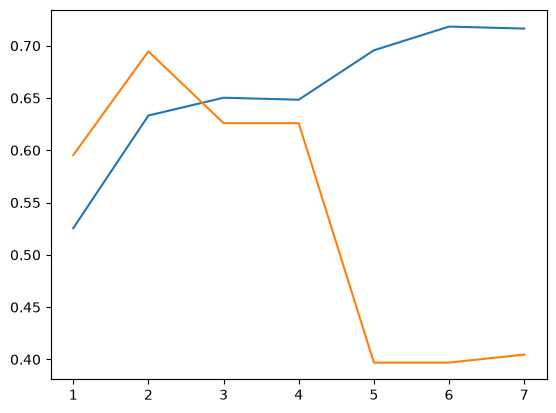

In [8]:
epoch_range = range(1,8)
plt.plot(epoch_range,history.history['accuracy'])
plt.plot(epoch_range,history.history['val_accuracy'])

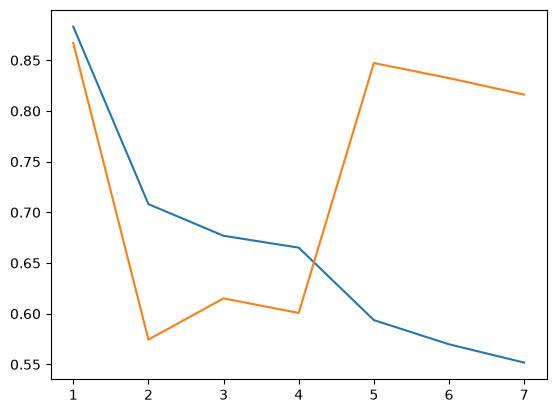

In [9]:
plt.plot(epoch_range,history.history['loss'])
plt.plot(epoch_range,history.history['val_loss'])

### Model Testing

In [10]:
img_path = r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Car_Bike_Dataset\Bikes\Bike (107).jpg"

# 1. Process image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0 
test_array = img_array.reshape(1, 224, 224, 3)

# 2. Predict (outputs a single probability between 0 and 1)
prediction = model.predict(test_array)[0][0]

# 3. Apply threshold for binary classification
predicted_class_index = 1 if prediction > 0.5 else 0

# 4. Map index to class name
class_names = ['Bike', 'Car'] 
predicted_class_name = class_names[predicted_class_index]

print(f"Prediction Probability: {prediction:.4f}")
print(f"Predicted Class is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Prediction Probability: 0.5399
Predicted Class is: Car


In [11]:
print(train_generator.class_indices)

{'Bikes': 0, 'Cars': 1}


### Using Transfer Learning 
cause own neural network not predictiing properly

In [3]:
from tensorflow.keras.applications import VGG16

In [4]:
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# 2. Freeze the weights so you don't waste time retraining them
base_model.trainable = False

# 3. Build your final model wrapper
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [5]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=20, # It will stop automatically much sooner
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.8582 - loss: 0.6507 - val_accuracy: 0.9618 - val_loss: 0.0756 - learning_rate: 0.0010
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 54s 3s/step - accuracy: 0.9509 - loss: 0.2087 - val_accuracy: 0.9771 - val_loss: 0.0464 - learning_rate: 0.0010
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9660 - loss: 0.1056 - val_accuracy: 0.9924 - val_loss: 0.0433 - learning_rate: 0.0010
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.9735 - loss: 0.0939 - val_accuracy: 0.9847 - val_loss: 0.0338 - learning_rate: 0.0010
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 56s 3s/step - accuracy: 0.9830 - loss: 0.0741 - val_accuracy: 0.9847 - val_loss: 0.0474 - learning_rate: 0.0010
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.9773 - loss: 0.0431 - val_accuracy: 0.9542 - val_loss: 0.1729 - learning_rate: 0.0010
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 62s 4s/step - accuracy: 0.9735 - loss: 0.0516 - val_accuracy: 

### Model Testing

In [7]:
img_path = r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Car_Bike_Dataset\Bikes\Bike (14).png"

# 1. Process image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0 
test_array = img_array.reshape(1, 224, 224, 3)

# 2. Predict (outputs a single probability between 0 and 1)
prediction = model.predict(test_array)[0][0]

# 3. Apply threshold for binary classification
predicted_class_index = 1 if prediction > 0.5 else 0

# 4. Map index to class name
class_names = ['Bike', 'Car'] 
predicted_class_name = class_names[predicted_class_index]

print(f"Prediction Probability: {prediction:.4f}")
print(f"Predicted Class is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction Probability: 0.0000
Predicted Class is: Bike


In [22]:
print(train_generator.class_indices)

{'Bikes': 0, 'Cars': 1}


### Save the Model

In [8]:
import json

# 1. Save the trained model
model.save('car_bike_classifier_vgg16.keras') 

# 2. the class list to match binary dataset
class_names = ['Bike', 'Car'] 
with open('car_bike_class_names.json', 'w') as f:
    json.dump(class_names, f)